<a href="https://colab.research.google.com/github/somustafa/plant_desease_detection/blob/main/lettuce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from roboflow import Roboflow


rf = Roboflow(api_key="rJ71U7KIJ2lOZ9spY68Y")

# kahi datasi yuklenir
project = rf.workspace("the-stove").project("lettuce-kgxfw")
dataset = project.version(2).download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Lettuce-2 in yolov8:: 100%|██████████| 44804/44804 [00:05<00:00, 8785.55it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
pip install roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 19.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 91.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 123.9 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [3]:
!pip install roboflow ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.7 MB/s eta 0:00:00


In [17]:
import yaml
import os

# Datasetin yerləşdiyi yolu müəyyən edirik
yaml_path = os.path.join(dataset.location, "data.yaml")

with open(yaml_path, 'r') as f:
    config = yaml.safe_load(f)

# Yolları Colab mühitinə uyğun mütləq yollara çeviririk
config['train'] = os.path.join(dataset.location, 'train/images')
config['val'] = os.path.join(dataset.location, 'valid/images')
# 'test' qovluğu v2-də olmaya bilər, ona görə ehtiyatlı oluruq
if 'test' in config:
    config['test'] = os.path.join(dataset.location, 'test/images')

# Düzgün yazma üsulu (os.open yox, sadəcə open)
with open(yaml_path, 'w') as f:
    yaml.dump(config, f)

print("data.yaml uğurla yeniləndi! Artıq təlimə (train) başlaya bilərsiniz.")

data.yaml uğurla yeniləndi! Artıq təlimə (train) başlaya bilərsiniz.


In [1]:
from ultralytics import YOLO

# Modeli yükləyirik
model = YOLO('yolov8n.pt')

# Sürətli təlim parametrləri:
model.train(
    data='/content/Lettuce-2/data.yaml',
    epochs=20,
    imgsz=416,        # 640-dan 416-ya saldıq (sürət üçün)
    batch=32,         # Daha çox şəkli eyni anda emal etsin
    augment=True,
    fraction=0.5,     # DATASETİN CƏMİ 10%-ni İSTİFADƏ ET (Əsas sirr buradadır!)
    device=0
)

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Lettuce-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.5, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f1d2444ef60>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0


image 1/1 /content/Lettuce-2/test/images/ba16_jpg.rf.442ccaf949268b1fc37515b1e983311c.jpg: 416x416 (no detections), 9.0ms
Speed: 1.9ms preprocess, 9.0ms inference, 0.8ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict


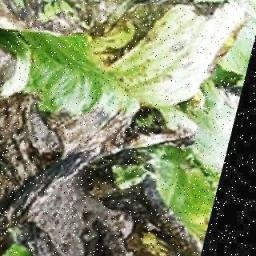


image 1/1 /content/Lettuce-2/test/images/163_JPG_jpg.rf.357d531a6eab6e83017d0474b77ae9c1.jpg: 416x416 1 normal, 10.6ms
Speed: 3.6ms preprocess, 10.6ms inference, 2.0ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict


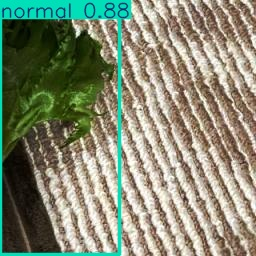


image 1/1 /content/Lettuce-2/test/images/11105_jpg.rf.1a20e3321507a8a4040441f5b61e2625.jpg: 416x416 1 Bacterial, 12.5ms
Speed: 1.4ms preprocess, 12.5ms inference, 2.1ms postprocess per image at shape (1, 3, 416, 416)
Results saved to /content/runs/detect/predict


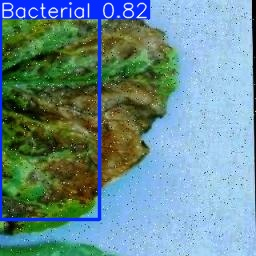

In [6]:
import glob
import random
from IPython.display import Image, display
import os

# Test qovluğundan təsadüfi 3 şəkil seçirik
test_images = glob.glob('/content/Lettuce-2/test/images/*.jpg')
sample_images = random.sample(test_images, 3)

# Bu şəkillər üzərində təxmin (prediction) edirik
for img_path in sample_images:
    results = model.predict(source=img_path, save=True, conf=0.25)
    # Nəticəni ekranda göstəririk
    display(Image(filename=f"runs/detect/predict/{os.path.basename(img_path)}"))

Nəticələr bu qovluqdan götürülür: train5


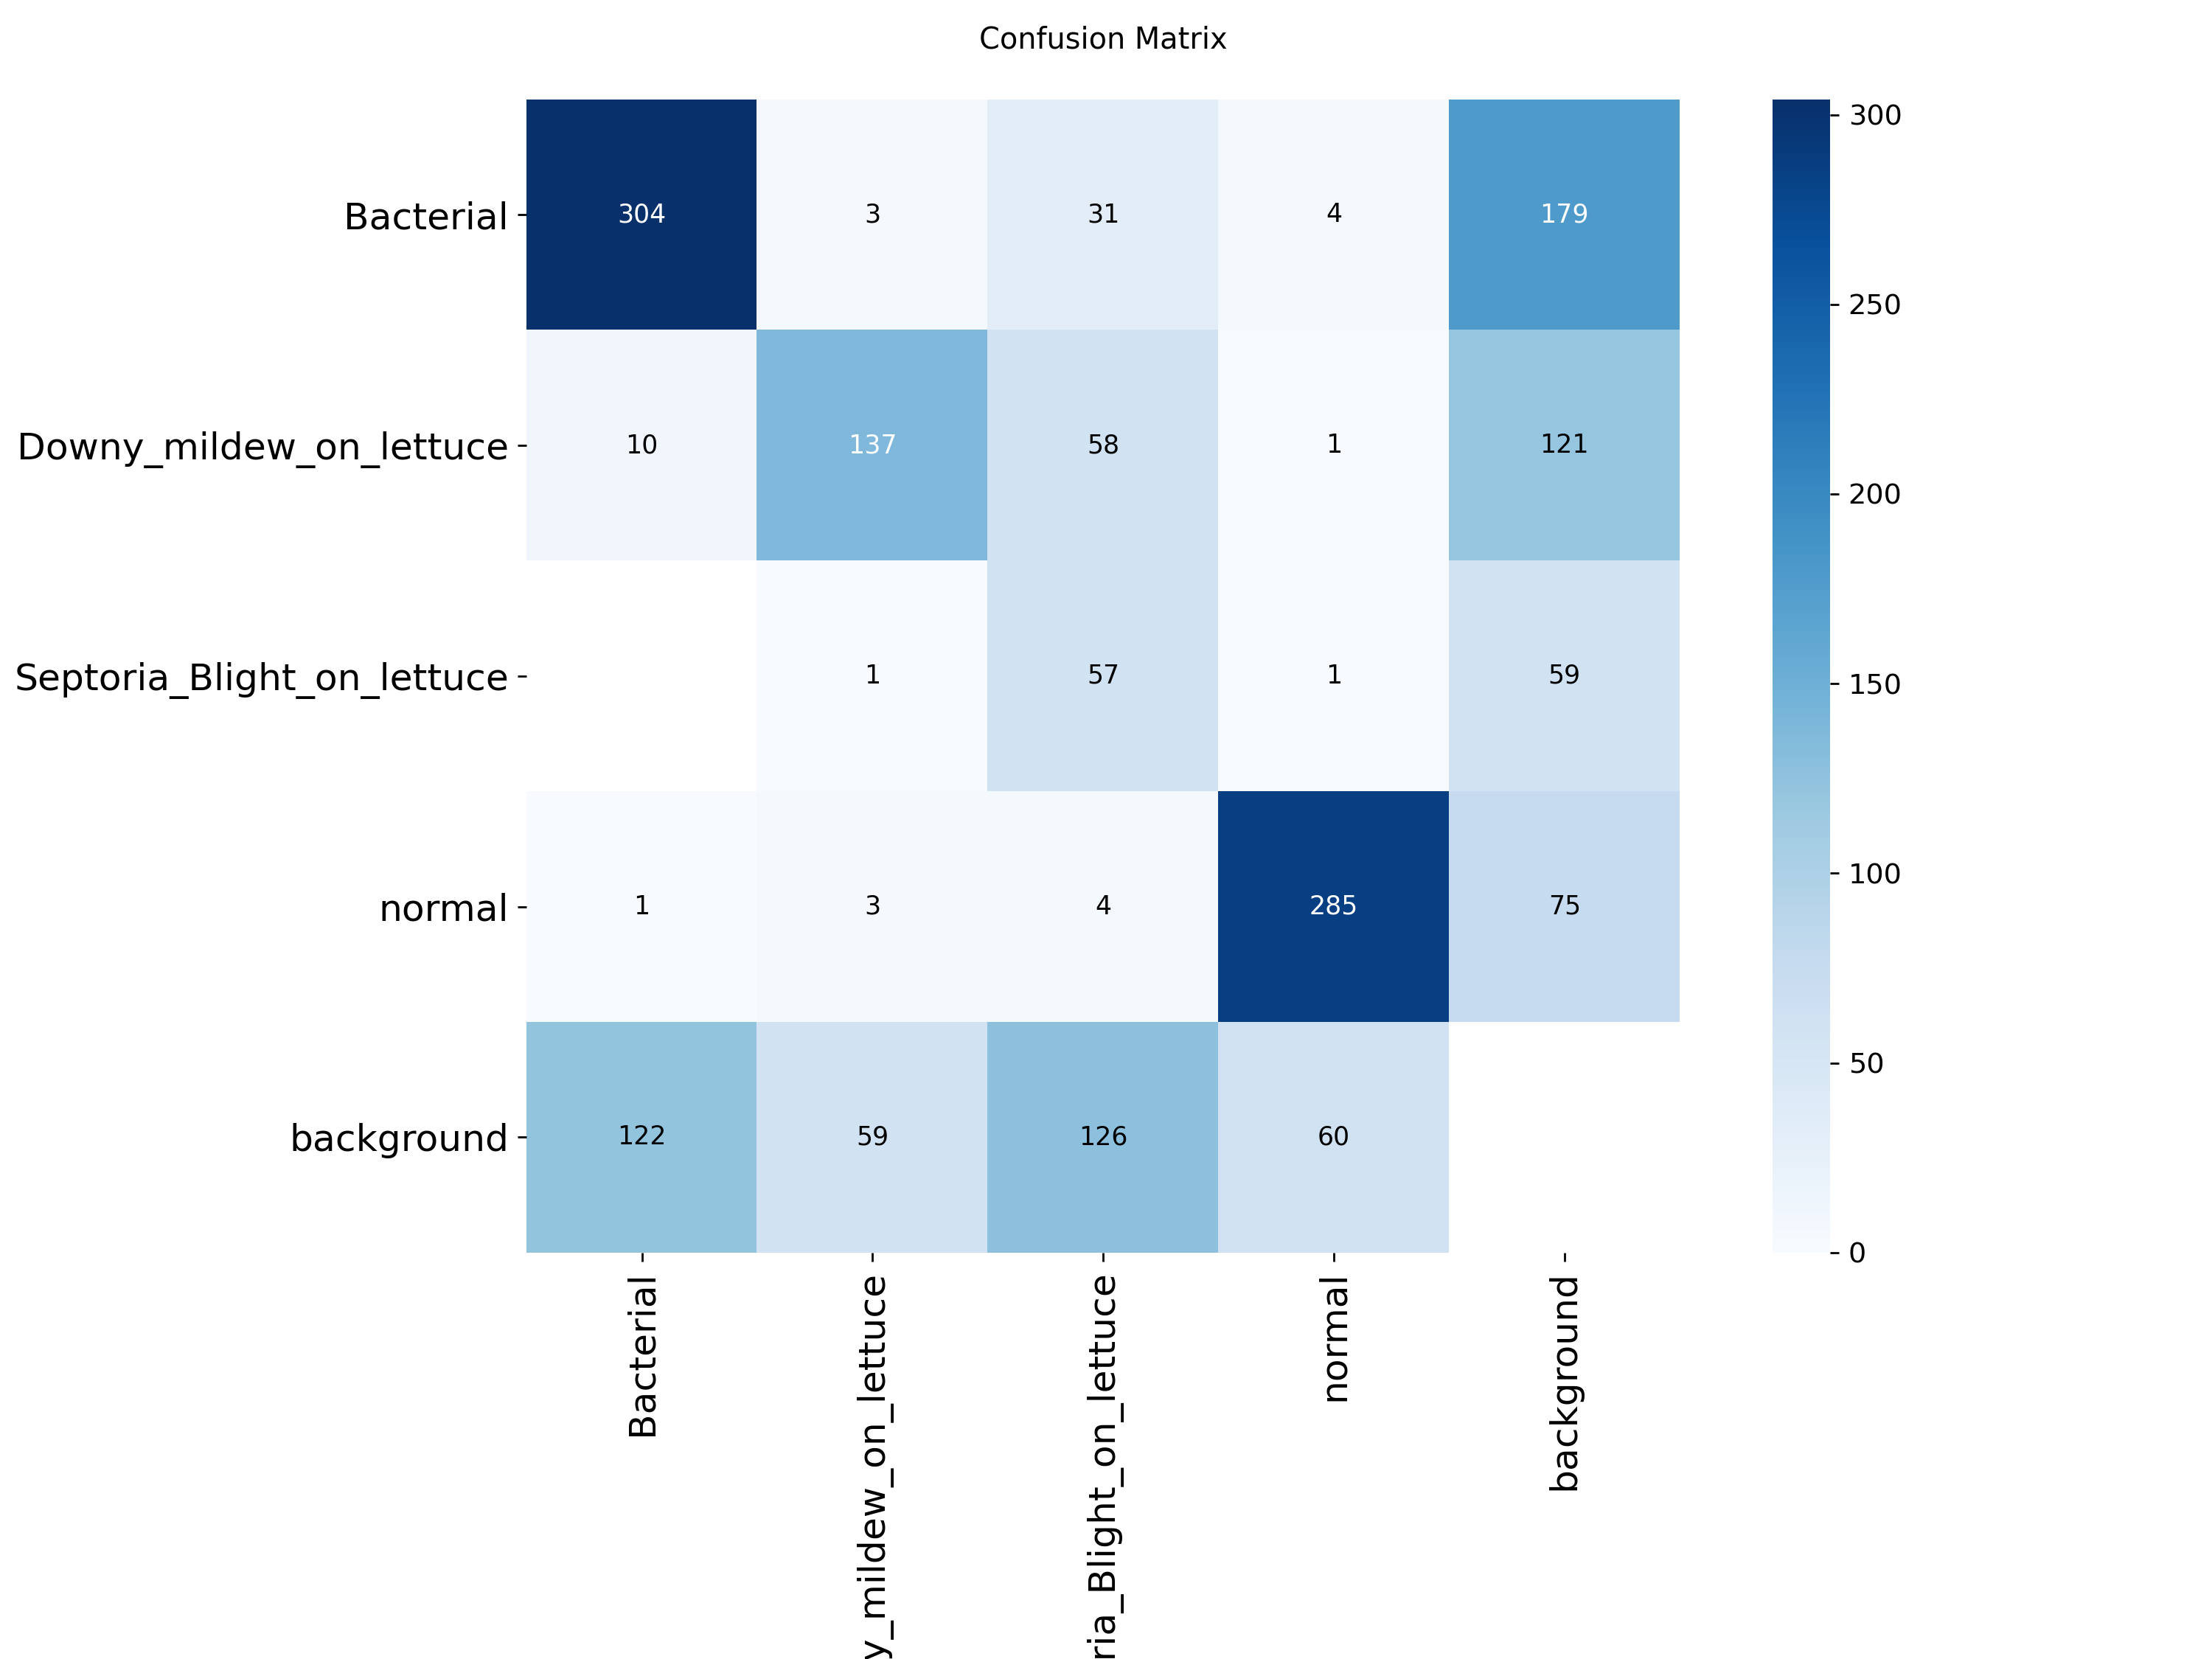

In [7]:
import os
from IPython.display import Image, display

# Ən son təlim qovluğunu tapırıq (train2 və ya sonuncusu)
latest_train = sorted([d for d in os.listdir('/content/runs/detect') if d.startswith('train')])[-1]
matrix_path = f'/content/runs/detect/{latest_train}/confusion_matrix.png'

if os.path.exists(matrix_path):
    print(f"Nəticələr bu qovluqdan götürülür: {latest_train}")
    display(Image(filename=matrix_path))
else:
    print("Confusion matrix tapılmadı. Bəlkə təlim tam bitməyib?")